<a href="https://colab.research.google.com/github/Text-Machine/mask-predict/blob/main/chr-paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/> </a>

# CHR Paper notebook

This notebook aims to reproduce all figures and tables that inform the analysis of the CHR paper.

In [ ]:
!git clone https://github.com/Text-Machine/mask-predict.git

In [ ]:
%cd mask-predict

In [ ]:
!pip install -q -e .

In [1]:
import pandas as pd
import json
from tqdm import tqdm
from explain import *
from pathlib import Path
from collections import Counter
import seaborn as sns

In [ ]:
%cd /content

In [ ]:
!gdown 125wfZ1P9MfFZ19XS2SCfallsnoNhLCUf

In [ ]:
!unzip -o "chr-data.zip"

note about explanation of data and choices to made here

In [139]:
collection,genre_suffix = 'blb',''
if collection == 'blb':
  genre_suffix = '_with_genre'

TargetMaskedToken = 'machine' # the token to be masked in the target sentence
try:
  import google.colab
  originalFolder = '.' # change to '.' when working in colab
  dataPath = '.' # change to '.' when working in colab 
  processedFolder = '.' # change '.' when working in colab
except:
  originalFolder = 'masking_data' # change to '.' when working in colab
  dataPath = 'input_data' # change to '.' when working in colab 
  processedFolder = 'gradient_data' # change '.' when working in colab

predCol = "pred_bert_1760_1900"
resultType = 'pred_kw_filtered' # pred | pred_kw_filter

print(f"This analysis focuses on '{TargetMaskedToken}'.")

This analysis focuses on 'machine'.


We are loading the data frame with deduplicated sentences.

In [140]:
df_sent_all = pd.read_csv(f'{dataPath}/{collection}_{TargetMaskedToken}_clusters{genre_suffix}_deduplicated.tsv', index_col=0, sep='\t').reset_index(drop=True)
print(f'We have {df_sent_all.shape[0]} unique sentences for the target token {TargetMaskedToken} in the {collection} collection.')


We have 77907 unique sentences for the target token machine in the blb collection.


In [226]:
# load the original sentences with the predicted tokens
df_sent = pd.read_csv(f'{dataPath}/{collection}_{TargetMaskedToken}{genre_suffix}_{resultType}.tsv', index_col=0, sep='\t').reset_index(drop=True)
print(f'We have {df_sent.shape[0]} sentences that produced human predictions for the target token {TargetMaskedToken} in the {collection} collection.')
df_ig = pd.read_csv(f'{processedFolder}/results_{collection}_{TargetMaskedToken}_{resultType}_processed.csv', index_col=0 )
print(f'We have {df_ig.shape[0]} explanations for the target token {TargetMaskedToken} in the {collection} collection.')


We have 20119 sentences that produced human predictions for the target token machine in the blb collection.
We have 2415322 explanations for the target token machine in the blb collection.


In [227]:
df_ig['id'].max()

np.int64(20118)

In [228]:
idx = 1000
df_ig[df_ig['id'] == idx].head(4)

,Token,Score,Target,id,Score_normalized,mask_syntax_relation,mask_constituent_relation,mask_token_distance,Target_position,Target_score,Sentence_length
118056,as,0.019606,brain,1000,0.003610,NaN,advmod^|advclv|depv,7.0,4,0.02,38
118057,long,0.082327,brain,1000,0.015157,NaN,advclv|depv,6.0,4,0.02,38
118058,as,0.108062,brain,1000,0.019895,NaN,mark^|advcl^|advclv|depv,5.0,4,0.02,38
118059,i,0.121662,brain,1000,0.022399,NaN,nsubj^|advcl^|advclv|depv,4.0,4,0.02,38


In [229]:
df_sent.iloc[idx]['currentSentence']

'As long as I could work that machine I was never entirely without an object and a pleasure.'

In [230]:
round((df_sent.shape[0] / df_sent_all.shape[0]) * 100 ,2)

25.82

Here we load the words that we selected as human prediction, i.e. these are words predicted by BLERT possible referring to human fillers for the masked machine token.

In [231]:
# with open(f'{dataPath}/100_freq_pred_BL_edit.txt') as f:
#     human_words = f.read().splitlines()
df_words = pd.read_csv(f"{dataPath}/word_human_clusters_v5_edit.csv")
human_words = list(df_words[df_words['human_likelihood'] > .1]['word'])

print(human_words[:10], len(human_words))

['man', 'men', 'woman', 'child', 'people', 'person', 'boy', 'girl', 'hands', 'children'] 225


We create a new column where filter the prediction, only retaining the human words.

In [232]:
for colName in ['pred_bert_contemporary', 'pred_bert_1760_1900']:
    df_sent[f'{colName}_human'] = df_sent[colName].apply(
        lambda x: {w:s for w, s in dict(eval(x)).items() if w in human_words})


We look at results by decade, therefore adding decade column to the data frames

In [233]:
df_sent_all['decade'] = df_sent_all['date'].apply(lambda x: int(x/10)*10)
df_sent['decade'] = df_sent['date'].apply(lambda x: int(x/10)*10)

### Analysis: Distribution of predictions

BLERT is not always equally convinced of it's predictions. Below we plot the distribution of it confidence scores for the human words it predicted instead of machine. These are the probabilities that a word fits the given context in the position of the masked token. We see that 

Distribution of the human prediction scores for the target token '{TargetMaskedToken}' in the {collection} collection.


<Axes: >

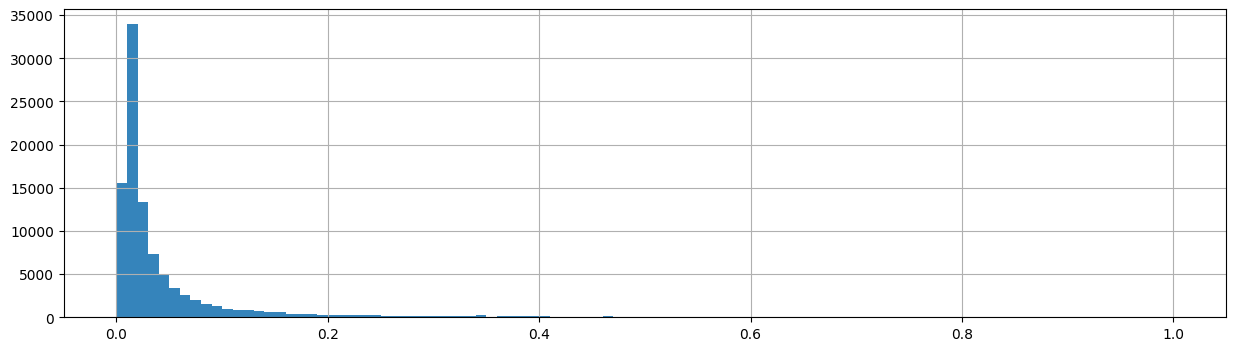

In [234]:
import itertools
scores_human = list(itertools.chain.from_iterable(df_sent['pred_bert_1760_1900_human'].apply(lambda x: list(x.values()))))
scores_all = list(itertools.chain.from_iterable(df_sent['pred_bert_1760_1900'].apply(lambda x: list(dict(eval(x)).values()))))

print("Distribution of the human prediction scores for the target token '{TargetMaskedToken}' in the {collection} collection.")
#pd.Series(scores_human).plot(kind='density')
pd.Series(scores_human).hist(bins=100, alpha=0.9, label='human predictions')
#pd.Series(scores_all).plot(kind='density', alpha=0.5)


### Analysis: timeline for all predictions

Below we plot the number of unique sentences containing 'human' predictions for masked machine tokens. We plot by decade, for all the human predictions, higher than a set confidence threshold. 

While maybe not drastically, we observe a small rise in the relative number of 'atypical' sentences or 'atypical' language use.

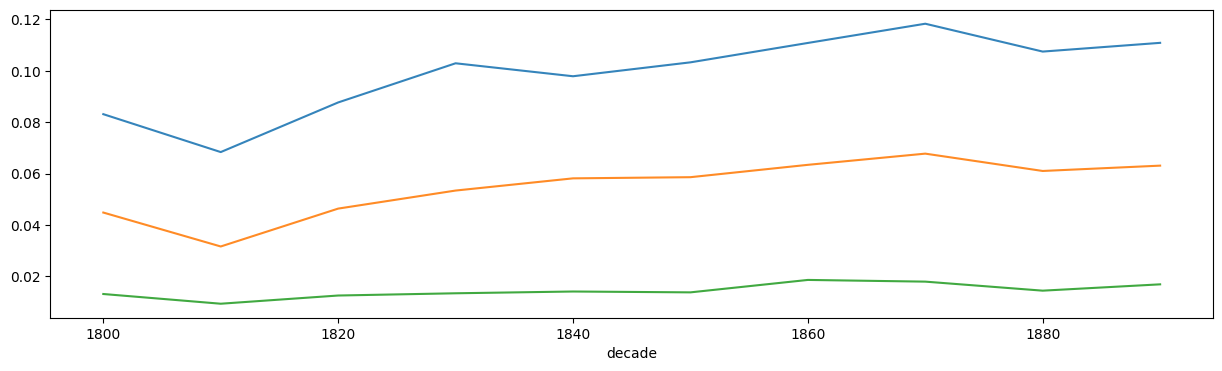

In [235]:
time_unit = 'decade' # change to 'date' for yearly analysis
thresholds = [0.1, 0.2, 0.5]
for threshold in thresholds:
    df_sent_filtered = df_sent[df_sent['pred_bert_1760_1900_human'].apply(lambda x: max(list(x.values())+[.0]) > threshold)]
    (df_sent_filtered.groupby(time_unit).size()/df_sent_all.groupby(time_unit).size()).loc[1800:1899].plot(alpha=0.9,
                                                                                                            title=f'', 
                                                                                                            xlabel=f'{time_unit}',
                                                                                                            figsize=(15, 4))


In [236]:
import seaborn as sns
for colName in [ 'pred_bert_1760_1900']:
    df_sent_all[f'{colName}_human'] = df_sent_all[colName].apply(
        lambda x: {w:s for w, s in dict(eval(x)).items() if w in human_words})

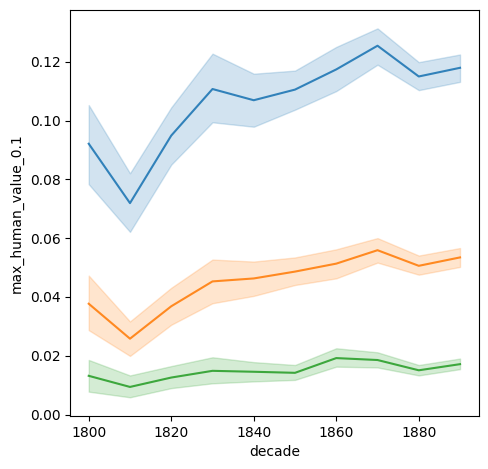

In [237]:
from matplotlib import rcParams

# figure size in inches
rcParams['figure.figsize'] = 5.27,5.27
thresholds = [0.1, 0.25, 0.5]
for threshold in thresholds:
    df_sent_all[f'max_human_value_{threshold}'] = df_sent_all['pred_bert_1760_1900_human'].apply(lambda x: max(list(x.values())+[.0]) >= threshold)
    sns.lineplot(y=f'max_human_value_{threshold}',x='decade',data=df_sent_all[df_sent_all['date'].between(1800,1899)], alpha=0.9)

<Axes: xlabel='decade', ylabel='max_human_value_0.1'>

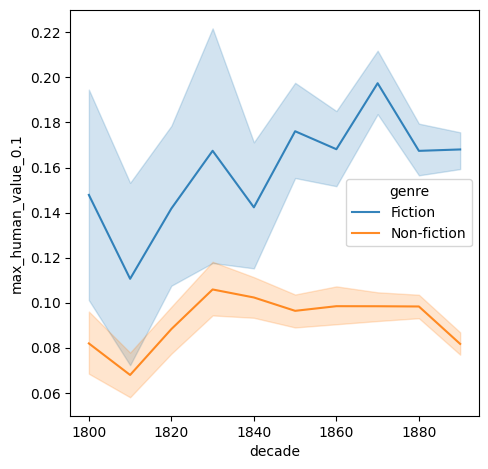

In [238]:
threshold = 0.1

df_sent_all[f'max_human_value_{threshold}'] = df_sent_all['pred_bert_1760_1900_human'].apply(lambda x: max(list(x.values())+[.0]) >= threshold)
sns.lineplot(y=f'max_human_value_{threshold}',x='decade',
             data=df_sent_all[df_sent_all['date'].between(1800,1899)],
             alpha=0.9, hue='genre', hue_order=['Fiction','Non-fiction'], palette=['#1f77b4', '#ff7f0e'], legend='full')

# Analysis for semantic clusters

In [239]:
df_words = pd.read_csv(f"{dataPath}/word_human_clusters_v5_edit.csv")

df_words.fillna('', inplace=True)
threshold = 0.1

In [240]:
cols = list(df_words.columns[2:])
for c in cols:
    exec(f"{c}2word = {{}}")

    for i, row in df_words.iterrows():
        if row['human_likelihood'] <= threshold:
            continue

        for hc in row[c].split(';'):
            exec(f"if hc not in {c}2word and hc != '': {c}2word[hc] = []")
            if hc != '':
                exec(f"{c}2word[hc].append(row['word'])")
    print(f"Created a dictionary for {c} with {len(eval(c+'2word'))} keys.")


Created a dictionary for chr_categories with 8 keys.
Created a dictionary for semantic_clusters with 11 keys.
Created a dictionary for human_subcategory with 23 keys.
Created a dictionary for pos_category with 3 keys.
Created a dictionary for animacy_tier with 5 keys.
Created a dictionary for domain_topic with 26 keys.
Created a dictionary for concreteness with 2 keys.
Created a dictionary for connotation_register with 4 keys.


In [241]:
df_ig_target = df_ig[['id','Target']].drop_duplicates(inplace=False)
df_ig_target = df_ig_target[df_ig_target.Target.isin(human_words)]
df_ig_target = df_ig_target.merge(df_words, left_on='Target', right_on='word', how='left')
 

In [242]:
visualise_col = 'human_subcategory'
df_ig_target[f'{visualise_col}_split'] = df_ig_target[visualise_col].apply(lambda x: x.split(';'))

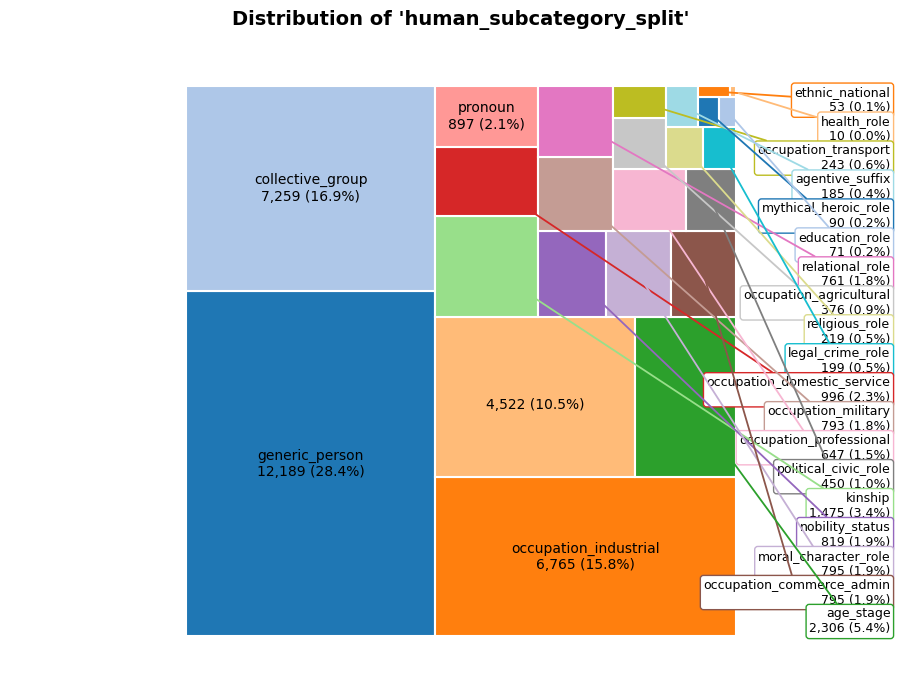

In [243]:
from explain.visualise import plot_semantic_squares
df_ig_target_exp = df_ig_target.explode(f'{visualise_col}_split').reset_index(drop=True)
fig, ax = plot_semantic_squares(df_ig_target_exp, column=f'{visualise_col}_split')

In [244]:
for k,v in chr_categories2word.items():
    print(f"{k}: {', '.join(v[:5])}")

women: woman, girl, women, girls, lady
age_status: child, boy, girl, children, boys
family_relation: child, children, father, mother, wife
body_part: hands, hand, body, heart, bodies
labour: hand, servant, engineers, workers, servants
servitude: master, slaves, slave, servant, servants
spiritual: mind, life, spirit, soul, heart
supernatural: god, monster, demon, devil, giant


<Axes: title={'center': 'Counts of the top 10 human_subcategory for the target token machine in the blb collection.'}, xlabel='human_subcategory_split'>

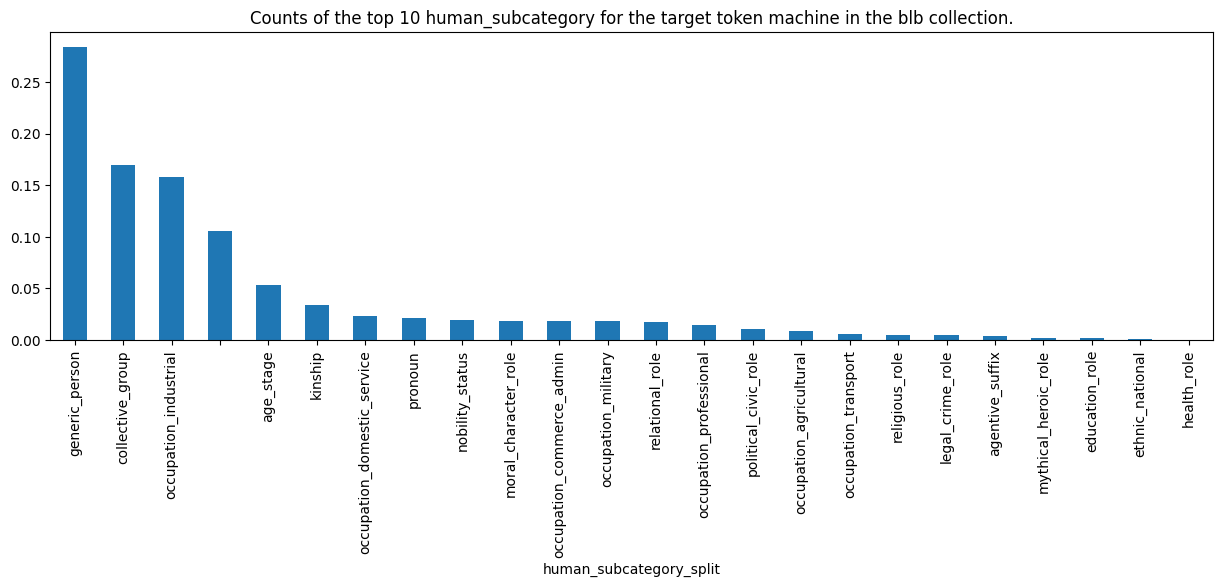

In [245]:
df_ig_target_exp[f'{visualise_col}_split'].value_counts(normalize=True).plot(kind='bar', figsize=(15, 4), title=f'Counts of the top 10 {visualise_col} for the target token {TargetMaskedToken} in the {collection} collection.')

In [246]:
len(chr_categories2word.keys())

8

Analyzing the theme of '['hands', 'hand', 'body', 'figure', 'heart', 'bodies', 'voice', 'feet', 'face', 'head', 'foot', 'eye', 'brain', 'eyes', 'tongue']' for the target token 'machine' in the blb collection.


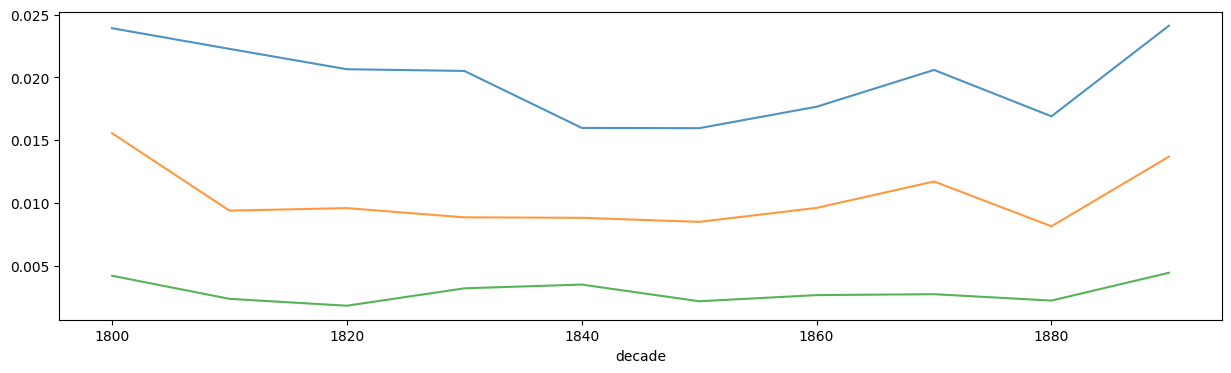

In [247]:
time_unit = 'decade' # change to 'date' for yearly analysis
thresholds = [ 0.1, 0.2, 0.5] # compare the results for different thresholds to see how the results change based on the confidence in the predictions
wordList = semantic_clusters2word['body_part']#hc2word['occupation_domestic_service'] # change these words to analyze a different theme
print(f"Analyzing the theme of '{wordList}' for the target token '{TargetMaskedToken}' in the {collection} collection.")
for threshold in thresholds:
    df_sent_filtered = df_sent[df_sent[f'{colName}_human'].apply(
        lambda x: max(list({w:s for w,s in x.items() if w in wordList}.values())+[.0]) > threshold
                )
            ]
    (df_sent_filtered.groupby(time_unit).size() / df_sent_all.groupby(time_unit).size()).loc[1800:1899].plot(alpha=0.8, 
                                                                                                             title=f'',
                                                                                                               xlabel=f'{time_unit}',
                                                                                                               figsize=(15, 4))


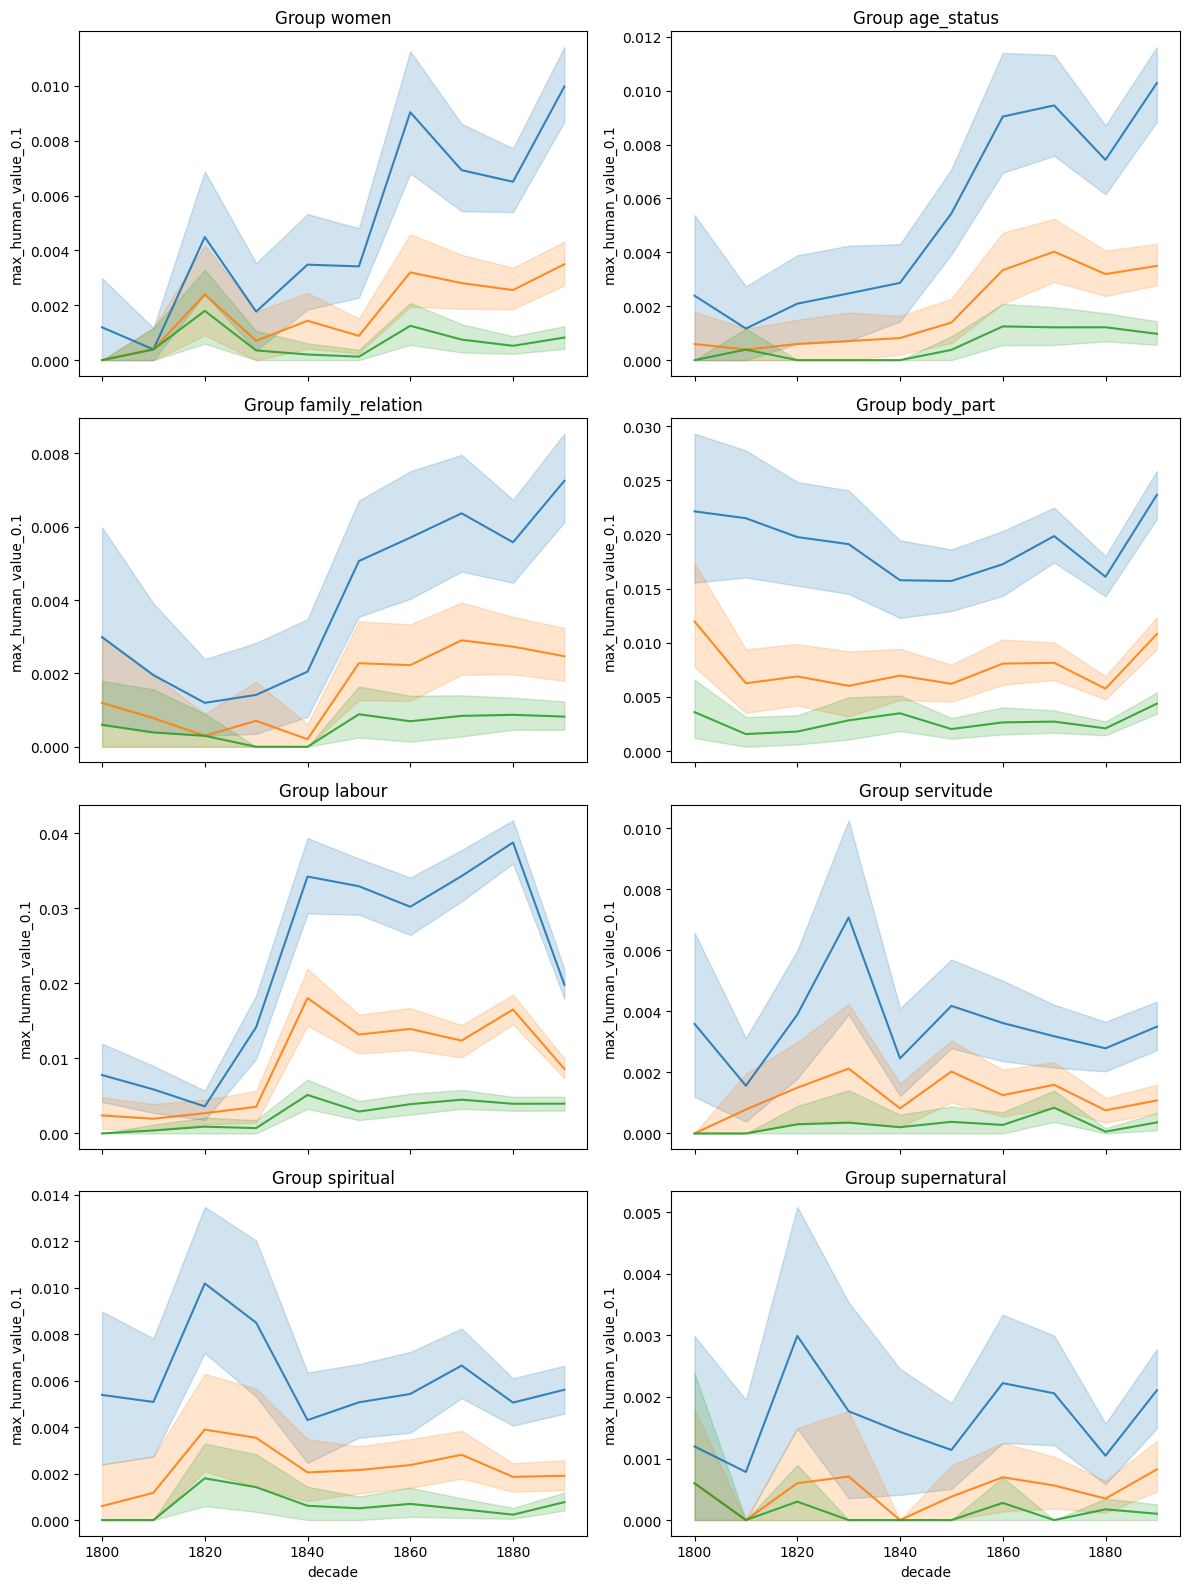

In [248]:
from matplotlib import rcParams
import matplotlib.pyplot as plt

# figure size in inches
rcParams['figure.figsize'] = 4.0,4.0
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(12, 16),
    sharex=True,      # optional
    sharey=False      # optional
)

thresholds = [0.1, 0.25, 0.5]
categories = list(chr_categories2word.keys())
axes = axes.flatten()

for i, ax in enumerate(axes):
    wordList = chr_categories2word[categories[i]]#hc2word['occupation_domestic_service'] # change these words to analyze a different theme
    for threshold in thresholds:
        df_sent_all[f'max_human_value_{threshold}'] = df_sent_all['pred_bert_1760_1900_human'].apply(
            lambda x: max(list({w:s for w,s in x.items() if w in wordList}.values())+[.0]) > threshold
            )
        sns.lineplot(y=f'max_human_value_{threshold}',x='decade',ax=ax, legend=False,
                 data=df_sent_all[df_sent_all['date'].between(1800,1899)], alpha=0.9,
                )
    
    ax.set_title(f"Group {categories[i]}")
    #ax.legend().remove() 

plt.tight_layout()
plt.show()

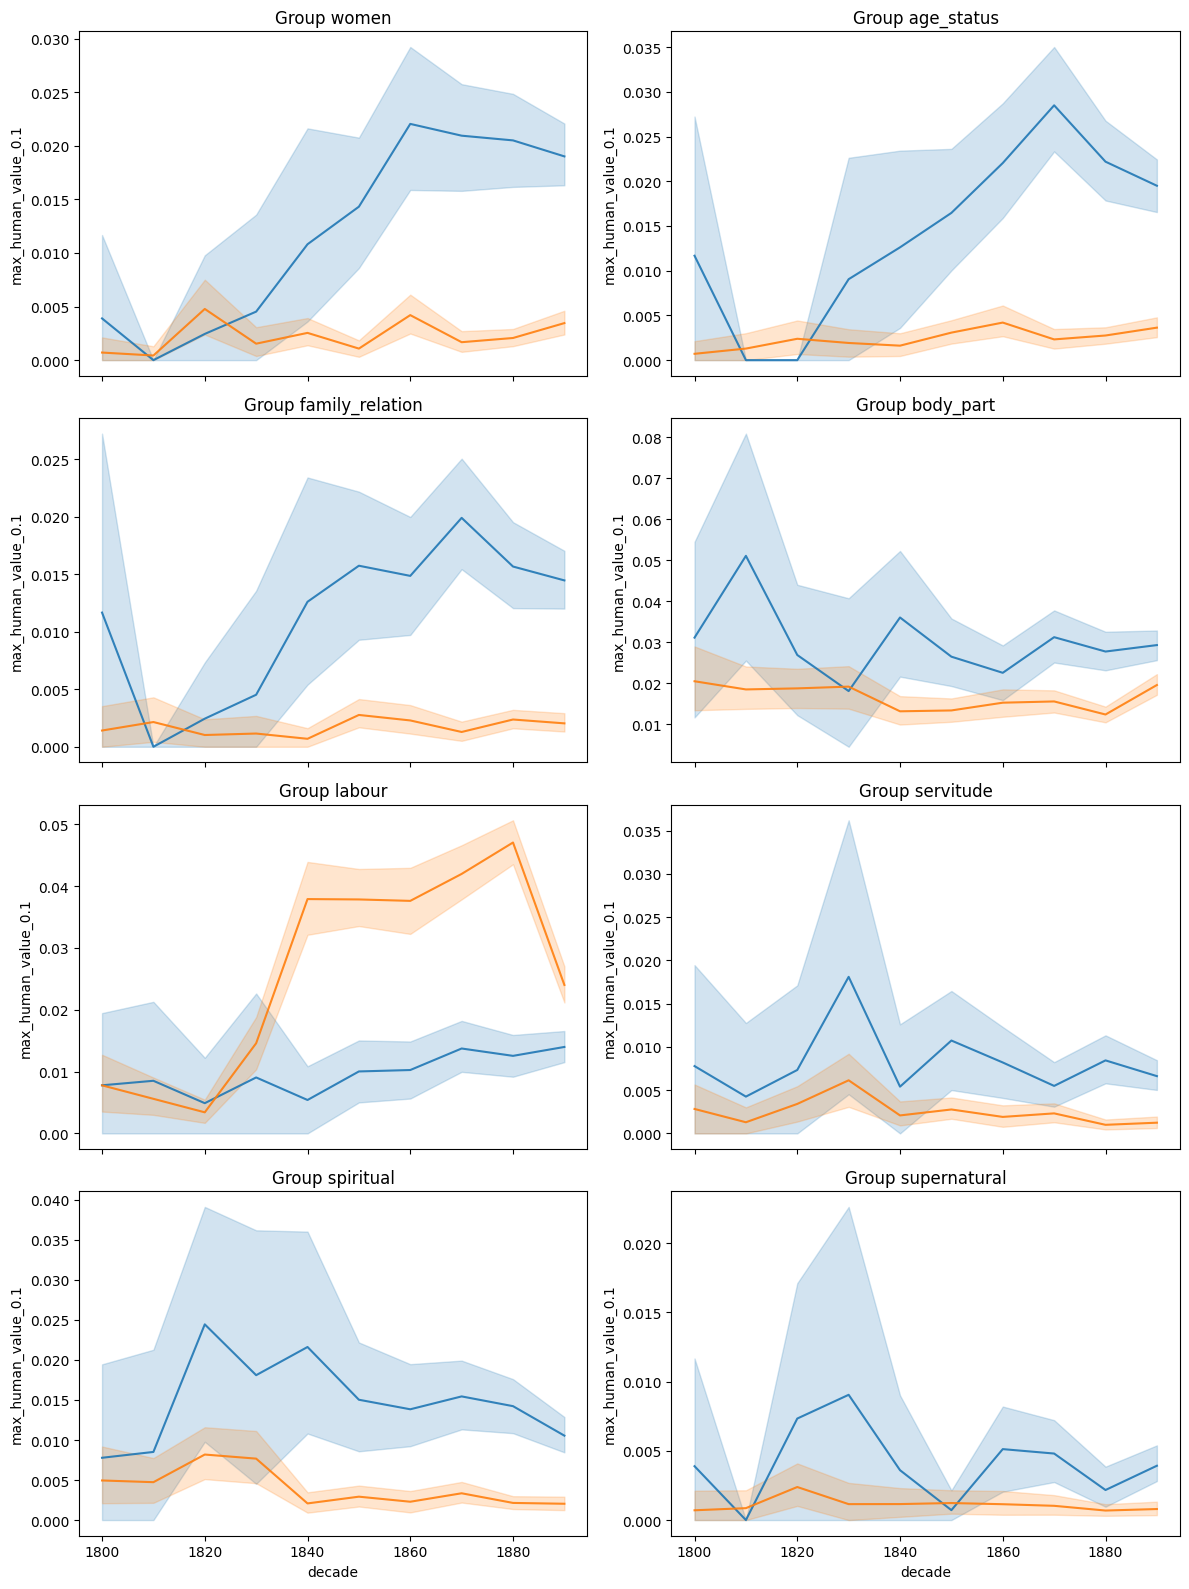

In [249]:
# figure size in inches
rcParams['figure.figsize'] = 4.0,4.0
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(12, 16),
    sharex=True,      # optional
    sharey=False      # optional
)

threshold = 0.1
categories = list(chr_categories2word.keys())
axes = axes.flatten()

for i, ax in enumerate(axes):
    wordList = chr_categories2word[categories[i]]#hc2word['occupation_domestic_service'] # change these words to analyze a different theme
    
    df_sent_all[f'max_human_value_{threshold}'] = df_sent_all['pred_bert_1760_1900_human'].apply(
            lambda x: max(list({w:s for w,s in x.items() if w in wordList}.values())+[.0]) > threshold
            )
    sns.lineplot(y=f'max_human_value_{threshold}',x='decade',ax=ax, legend=False,
                 hue='genre', hue_order=['Fiction','Non-fiction'],
                 data=df_sent_all[df_sent_all['date'].between(1800,1899)], alpha=0.9,
                )
    
    ax.set_title(f"Group {categories[i]}")
    #ax.legend().remove() 

plt.tight_layout()
plt.show()

### Analysis: timeline for a selected thema

By changing the `wordList` variable below, we can plot timelines for specific subset or theme of predictions. 

The children theme shows a pronounced upward trend. This could be one of the subquestions we address in the paper: how and why the increasing confusion of child and machine?

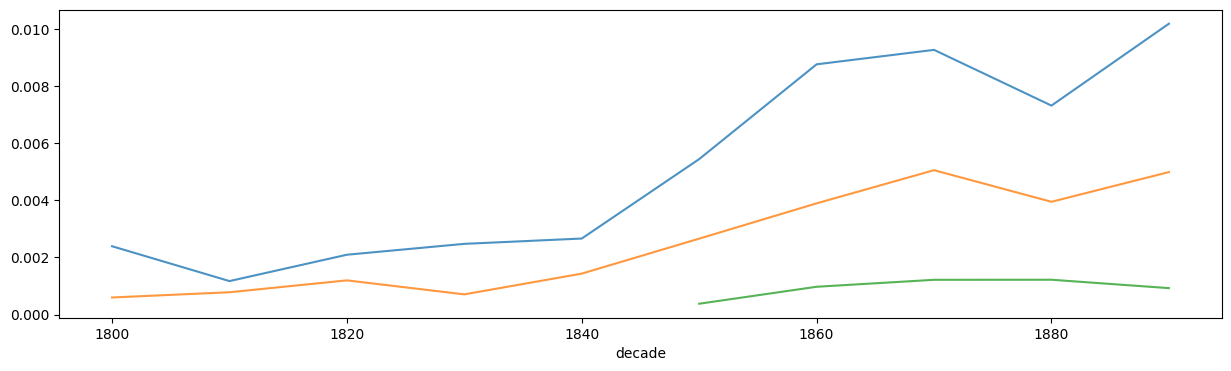

In [250]:
time_unit = 'decade' # change to 'date' for yearly analysis
thresholds = [ 0.1, 0.2, 0.5] # compare the results for different thresholds to see how the results change based on the confidence in the predictions
wordList = ['child','children', 'boy','boys','girl','girls']  # change these words to analyze a different theme
for threshold in thresholds:
    df_sent_filtered = df_sent[df_sent[f'{colName}_human'].apply(
        lambda x: max(list({w:s for w,s in x.items() if w in wordList}.values())+[.0]) > threshold
                )
            ]
    (df_sent_filtered.groupby(time_unit).size() / df_sent_all.groupby(time_unit).size()).loc[1800:1899].plot(alpha=0.8, 
                                                                                                             title=f'',
                                                                                                               xlabel=f'{time_unit}',
                                                                                                               figsize=(15, 4))


### Analysis: results by genre

The results hold when splitting the data by genre. Upward trend appears in both fiction and non-fiction but, more articulate in the form}er.

<Axes: xlabel='decade', ylabel='0'>

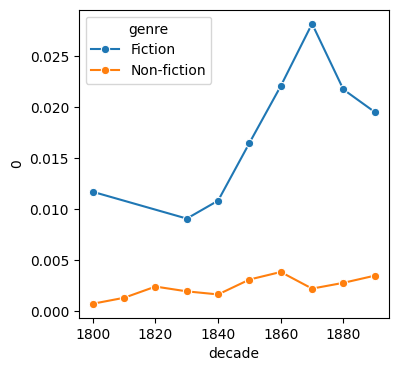

In [251]:

time_unit = 'decade' # change to 'date' for yearly analysis
threshold = 0.1 # use higher thresholds for more conservative analysis, i.e. only sentences with a high probability of the tokens in wordList being predicted are included in the analysis
wordList = ['child','children', 'boy','boys','girl','girls'] # change these words to analyze a different theme

df_sent_filtered = df_sent[df_sent['pred_bert_1760_1900_human'].apply(
    lambda x: max(list({w:s for w,s in x.items() if w in wordList}.values())+[.0]) > threshold
    )]
plot_df = df_sent_filtered.groupby([time_unit, 'genre']).size() / df_sent_all.groupby([time_unit, 'genre']).size()
plot_df_rel = (df_sent_filtered.groupby([time_unit, 'genre']).size() / df_sent_all.groupby([time_unit, 'genre']).size()).reset_index()
sns.lineplot(data=plot_df_rel, x=time_unit, y=0, hue='genre', marker='o')

<Axes: xlabel='decade', ylabel='max_human_value_0.1'>

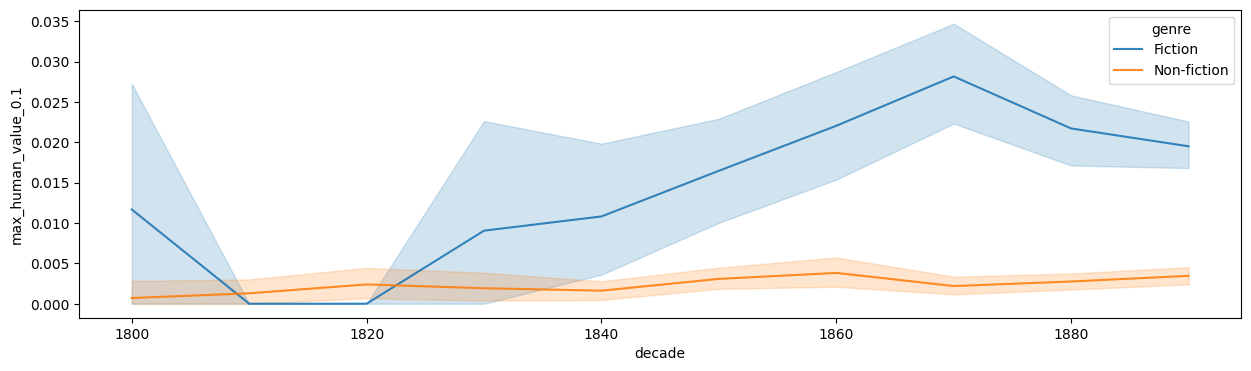

In [252]:
from matplotlib import rcParams

# figure size in inches
rcParams['figure.figsize'] = 15.0,4.0
threshold = 0.1
#wordList = semantic_clusters2word['body_part']#hc2word['occupation_domestic_service'] # change these words to analyze a different theme
wordList = ['child','children', 'boy','boys','girl','girls'] # change these words to analyze a different theme
df_sent_all[f'max_human_value_{threshold}'] = df_sent_all['pred_bert_1760_1900_human'].apply(
        lambda x: max(list({w:s for w,s in x.items() if w in wordList}.values())+[.0]) > threshold
        )
sns.lineplot(y=f'max_human_value_{threshold}',x='decade',
                 data=df_sent_all[df_sent_all['date'].between(1800,1899)], 
                 hue='genre',hue_order=['Fiction', 'Non-fiction'],alpha=0.9)

### Analysis: Distribution of prediction

Which human words does BLERT predict instead of ''machine''? And why? 

We refined the analysis below by allowing to refine the threshold, i.e. to focus only on "confident" predictions etc.

In [253]:

thresholds = [0.01,0.1, 0.25, 0.5 ]# change this threshold to see how the results change based on the confidence in the predictions


In [254]:
dfs_temp = []
for threshold in thresholds:

    df_sent_filtered = df_sent[df_sent[f'{colName}_human'].apply(lambda x: max(list(x.values())+[0]) > threshold)]
    preds = Counter([w for l in df_sent_filtered[f'{colName}'].values for w,s in eval(l) if (w in human_words) & (s > threshold) ])
    df_threshold = pd.DataFrame([(w, c/sum(preds.values())) for w, c in preds.most_common(100)]
             ).rename(columns={0: 'Predicted token', 1: f'threshold={threshold}'}
                      ).set_index('Predicted token'
                                  )#.plot(kind='bar', title=f'Top 100 predicted tokens for the target token {TargetMaskedToken}.', 
                                   #      ylabel='Count', xlabel='Predicted token', figsize=(15,5))
    dfs_temp.append(df_threshold)

<Axes: title={'center': 'Top 25 predicted tokens for the target token machine.'}, xlabel='Predicted token', ylabel='Probability'>

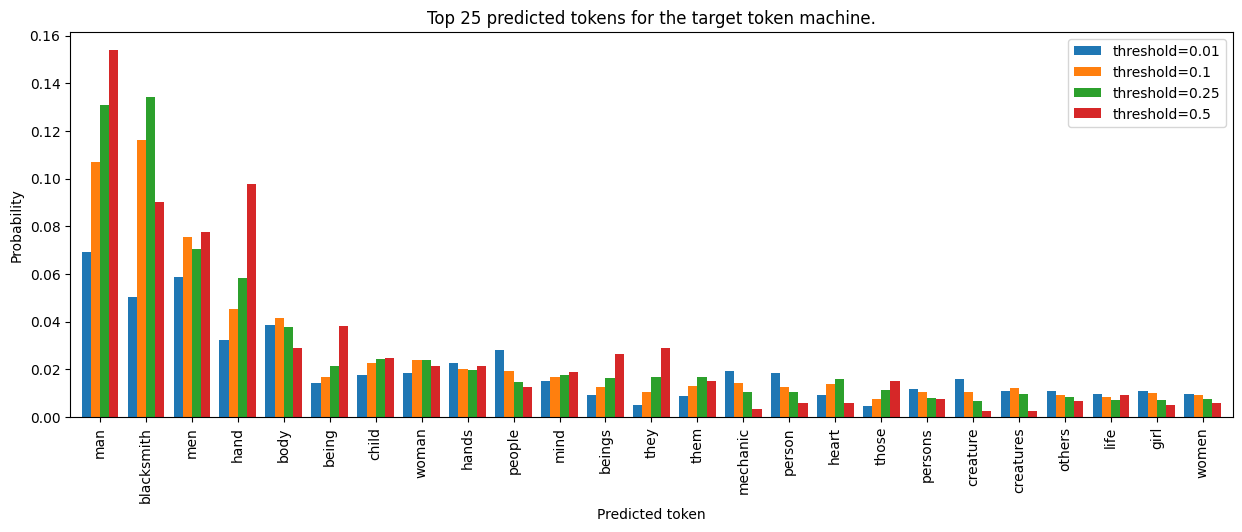

In [255]:
prob_by_token = pd.concat(dfs_temp, axis=1)
prob_index =prob_by_token.mean(axis=1).sort_values(ascending=False).index

prob_by_token.loc[prob_index[:25]].plot(kind='bar', title=f'Top 25 predicted tokens for the target token {TargetMaskedToken}.', 
                             ylabel='Probability', xlabel='Predicted token',width=0.8, figsize=(15,5))


In [256]:
list(chr_categories2word.keys())

['women',
 'age_status',
 'family_relation',
 'body_part',
 'labour',
 'servitude',
 'spiritual',
 'supernatural']

In [257]:
dfs_temp = []
wordList = []
wordList = chr_categories2word['age_status']
print(wordList)
for threshold in thresholds:

    df_sent_filtered = df_sent[df_sent[f'{colName}_human'].apply(
        lambda x: max(list({w:s for w,s in x.items() if w in wordList}.values())+[.0]) > threshold
        )]
    preds = Counter([w for l in df_sent_filtered[f'{colName}'].values for w,s in eval(l) if (w in wordList) & (s > threshold) ])
    df_threshold = pd.DataFrame([(w, c/sum(preds.values())) for w, c in preds.most_common(100)]
             ).rename(columns={0: 'Predicted token', 1: f'threshold={threshold}'}
                      ).set_index('Predicted token'
                                  )#.plot(kind='bar', title=f'Top 100 predicted tokens for the target token {TargetMaskedToken}.', 
                                   #      ylabel='Count', xlabel='Predicted token', figsize=(15,5))
    dfs_temp.append(df_threshold)

['child', 'boy', 'girl', 'children', 'boys', 'girls', 'baby', 'lad', 'infant', 'lads', 'youth', 'youths']


<Axes: title={'center': 'Top 25 predicted tokens for the target token machine.'}, xlabel='Predicted token', ylabel='Probability'>

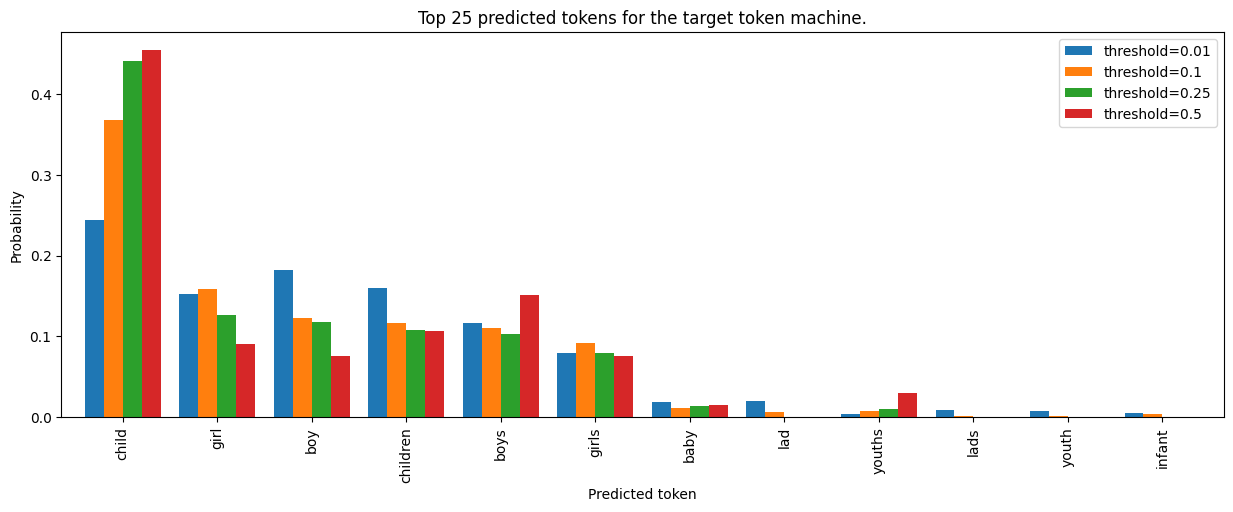

In [258]:
prob_by_token = pd.concat(dfs_temp, axis=1)
prob_index =prob_by_token.mean(axis=1).sort_values(ascending=False).index

prob_by_token.loc[prob_index[:25]].plot(kind='bar', title=f'Top 25 predicted tokens for the target token {TargetMaskedToken}.', 
                             ylabel='Probability', xlabel='Predicted token',width=0.8, figsize=(15,5))


### Analysis: explainability

Which words drive the predictions, and especially, how to interpet this increasing "confusion" or children with machines? What does it tell us about changes in the discourse about machines.

What we compute is not just how words contribute to the prediction, this tells us often more about what type of sentences are included in our data. We look at which words explain the difference between machine and human words, i.e. which words drive the prediction towards 'human' and away from 'machine'.

More technically, for each word in the sentence we compute pairwise differences between ''machine'' and ''human'' predictions (for the masked token) for each token in the sentence.

In [259]:
# Create row order within each id and Target
df_ig["row_idx"] = df_ig.groupby(["id", "Target"]).cumcount()

# Extract machine/machines scores
machine_scores = (
    df_ig[df_ig["Target"].isin(["machine", "machines"])]
    [["id", "row_idx", "Score_normalized"]]
    .rename(columns={"Score_normalized": "machine_score"})
)

# Match each row with the corresponding machine row
df_ig = df_ig.merge(
    machine_scores,
    on=["id", "row_idx"],
    how="left"
)

# Subtract
df_ig["diff"] = df_ig["Score_normalized"] - df_ig["machine_score"]

# Optional: remove helper column
df_ig.drop(columns=["row_idx", "machine_score"], inplace=True)

In [260]:
df_ig[(df_ig['id'] == 11)].Target.unique()

<ArrowStringArray>
['girls', 'machine']
Length: 2, dtype: str

In [261]:
df_ig[(df_ig['id'] == 11) & (df_ig['Target'].isin(['machine', 'machines']))][['Target', 'Score_normalized', 'diff']].head(3)

,Target,Score_normalized,diff
1547,machine,0.000787,0.0
1548,machine,0.016184,0.0
1549,machine,0.009033,0.0


In [262]:
df_ig[(df_ig['id'] == 11) & (df_ig['Target'].isin(['girl']))][['Target', 'Score_normalized', 'diff']].head(3)

,Target,Score_normalized,diff


## Analysis: Explanation scores across all human word predictions

Below is a general analysis, highlighting which context words explain the drifting aways of explanations from the machine.

The threshold, again, regulates, the confidence.

The `df_result` dataframe shows the words that exhibit the highest difference between machine and human words. Below we provide tools for analysing these words, and the sentences, in which they appear, in more depth.

In [263]:
threshold = 0.25

targetTokens = ['machine','machines'] # we look at the predictions for all the non machine words
df_comparisonConcept = df_ig[
    (~df_ig['Target'].isin(targetTokens)) & # we exclude the target token itself, as we are interested in other tokens that are predictive of the contrastive concept
    (df_ig['Target_score'].between(threshold, 1.0))
                ].groupby('Token').agg(
                        count=('id', 'count'),identifiers=('id', set),avg_diff=('diff', 'mean'), avg_score=('Score_normalized', 'mean')
                    ).reset_index()


In [264]:
# please note that this repeats sentences, this acros all sentences with all the filtered keywords
min_count = 20
df_result = df_comparisonConcept[df_comparisonConcept['count'] >= min_count].sort_values(by='avg_diff', ascending=False)
df_result.head(10)

,Token,count,identifiers,avg_diff,avg_score
6865,human,243,"{12288, 15872, 9730, 8195, 12803, 17927, 1544, 10763, 15373, 2574, 4118, 2074, 540, 13340, 15397, 5161, 14379, 1580, 16943, 9270, 6203, 19004, 9789, 5182, 5696, 9284, 19532, 14413, 16466, 8791, 87...",0.016999,0.034923
10819,quartz,22,"{9152, 5285, 13510, 5287, 5288, 13447, 13543, 13573, 13642, 13485, 13657, 18109, 13648, 441, 10746, 13659, 13629, 17215}",0.013653,0.025391
3649,crushing,27,"{5507, 9245, 8995, 5285, 5287, 5288, 13484, 13612, 13630, 13634, 7112, 13642, 13519, 13648, 13521, 13527, 13659, 13662, 13543, 13551}",0.013019,0.030993
9772,party,26,"{19845, 12312, 17177, 5534, 19875, 6823, 2216, 2217, 13607, 13483, 3137, 12867, 13508, 16071, 6857, 10320, 17361, 12884, 9302, 12887, 13917, 19685, 3690, 6386}",0.011749,0.029555
1047,animated,30,"{7938, 12679, 3209, 1802, 2062, 11030, 6296, 8986, 925, 18589, 2465, 2466, 19370, 9899, 17324, 18734, 2736, 5426, 13112, 16196, 19960, 9294, 1756, 12260, 2918, 14697, 15854, 14327, 19064}",0.010311,0.016292
5496,fellow,24,"{1793, 11396, 16534, 16284, 13343, 10913, 5155, 17059, 10028, 1329, 12984, 15547, 11581, 14401, 15684, 10952, 17103, 6489, 7012, 14184, 5105, 1405}",0.010171,0.016117
6124,girls,22,"{15942, 19642, 9801, 15497, 4907, 3084, 7245, 5934, 4463, 16140, 18538, 19408, 4371, 8597, 16085, 12152, 12762, 19643}",0.010089,0.021113
1044,animal,35,"{5376, 4997, 5639, 1550, 3087, 5910, 11542, 5528, 13084, 19869, 16798, 2467, 6308, 15656, 6826, 11434, 15658, 19001, 443, 15167, 14273, 19907, 4551, 5968, 7378, 13268, 16221, 10592, 15585, 98, 471...",0.009380,0.032554
7954,led,21,"{15872, 3718, 1415, 4367, 8994, 19878, 6189, 11312, 14003, 18615, 5591, 5849, 3041, 3691, 4332, 15216, 6515, 19955, 19830, 18426}",0.009085,0.011303
12693,spoke,21,"{9345, 11787, 911, 16655, 3094, 4376, 8612, 5414, 7975, 8873, 8241, 3506, 4405, 11708, 13377, 9283, 14190, 4980, 1019, 17790}",0.008107,0.008190


## Analysis: Explanation scores for a specific theme


The code below, repeats the contextual analyis, but focussing on specific theme, defined by the `comparisonTokens` variable. Here we highlight which context words explain the drifting aways of explanations from the machine, with regard to a specific theme.

The `threshold`  regulates, the confidence.

`comarisonTokens` defines a set of words which we compare against machine predictions.

The `df_result` dataframe shows the words that exhibit the highest difference between machine and human words. Below we provide tools for analysing these words, and the sentences, in which they appear, in more depth.

In [265]:
list(chr_categories2word.keys())

['women',
 'age_status',
 'family_relation',
 'body_part',
 'labour',
 'servitude',
 'spiritual',
 'supernatural']

In [266]:


#comparisonTokens = ['child','children', 'boy','boys','girl','girls']
comparisonTokens = chr_categories2word['age_status']
df_comparisonConcept = df_ig[
    (df_ig['Target'].isin(comparisonTokens)) & \
    (df_ig['Target_score'].between(0.4, 1.0)) # we exclude the target token itself, as we are interested in other tokens that are predictive of the contrastive concept
                ].groupby('Token').agg(
                        count=('id', 'count'),identifiers=('id', set),avg_diff=('diff', 'mean'), avg_score=('Score_normalized', 'mean')
                    ).reset_index()


In [267]:
# please note that this repeats sentences, this acros all sentences with all the filtered keywords
min_count = 5
df_result = df_comparisonConcept[df_comparisonConcept['count'] >= min_count].sort_values(by='avg_score', ascending=False)
df_result.head(20)

,Token,count,identifiers,avg_diff,avg_score
556,man,5,"{4384, 19520, 5255, 3663, 18589}",0.003898,0.031245
380,girl,5,"{7858, 6043, 12723, 7895}",0.008154,0.027001
580,mere,22,"{10642, 14483, 1697, 11171, 8873, 4907, 19255, 12857, 16442, 4795, 19259, 1087, 11584, 14016, 3663, 1491, 13140, 4565, 10969, 8160, 19043, 14824}",0.001020,0.026541
381,girls,10,"{15497, 18538, 4907, 16140, 4463, 19408, 16085, 19643}",0.012975,0.022839
133,boys,8,"{4907, 4463, 9552, 3701, 14010, 4795, 8126}",0.007653,0.022590
815,sewing,6,"{8644, 16140, 18256, 19408, 15538, 5435}",0.001638,0.021340
538,like,20,"{14211, 5785, 6043, 16673, 12579, 19624, 16427, 2732, 11185, 13116, 1087, 8902, 19532, 9552, 3285, 2151, 16245, 10876, 8959}",-0.002823,0.019040
170,child,5,"{2151, 13096, 4364, 19532, 13140}",-0.003589,0.018525
544,little,11,"{4355, 2151, 11050, 16427, 18538, 19532, 9552, 1397, 13813, 16085}",0.001703,0.016922
172,children,6,"{5255, 2671, 1397, 16085, 1021, 15743}",0.005533,0.015183


In [268]:
#df_result.avg_score.plot(kind='hist', bins=100, title=f'Histogram of average scores for tokens predictive of the contrastive concept.', xlabel='Average score', ylabel='Count')

# Analysis: Zooming in on sentences based on context words

You can zoom in a sentences with using the predictive context words. Change the `id` variable below with one of the index numbers of the`df_result` dataframe.

The sentence are ranked, with examples where the context word obtains the highest scores, first.

You can change the following variable:

- `id` selected from the `df_result` dataframe
- `sort_value` how do sort the sentences, i.e. where the impact of the target word is thelargest ('Score_normalized') or makes the biggest difference ('diff')

In [269]:
pd.set_option('display.max_colwidth', 200)

In [270]:
id = 172 #1637
sort_value = 'diff' #'Score_normalized' | 'diff'


identifiers_ranked = df_ig.loc[df_ig['id'].isin(list(df_result.loc[id].identifiers)) \
                             & (df_ig['Token']==df_result.loc[id].Token) \
                             & df_ig['Target'].isin(comparisonTokens)
                             
                             ].sort_values(by=sort_value, ascending=False)['id'].unique()
sentences_ranked = df_sent.iloc[list(identifiers_ranked)].head(20)
sentences_ranked.currentSentence

1397                  I am very glad I am here, for my machines are my own children, and I look on their little failings with a parent 's eye, and lead them into the path of duty with gentleness and firmness.
2671     The work of these children, as of all the others employed at the Cotton Mills, of all ages, and sexes, is comparatively easy; they have only to set the machines to work, watch them, and feed them ...
1021     DICKS ' ENGLISH LIBRARY OF STANDARD WORKS CHAPTER XXXVII. nil matters with my wife, and taken leave of her and the children, I charged them not to stir out of the grotto till I was gone; and leavi...
16085    Groups of soldiers and peasantry stood listening by the churchyard walls, and then little girls were clustering round and dancing in careless glee, as children dance to time in Italy, in England, ...
5255                                       Errare est humanum, and these machines, in spite of the ex - Q 226 THE ENGLISH AT HOME. ce Uency of the work, being after

In [271]:
# Optional: save and expeort sentences
name = 'child'
outPath = Path('sentences')
outPath.mkdir(exist_ok=True)
sentences_ranked.to_csv(outPath / f'{name}_sentences.csv', index=False)

In [220]:
modelName = "Livingwithmachines/bert_1760_1900"
explainer = MaskedLMExplainer(model_name=modelName, device=pick_device())

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: Livingwithmachines/bert_1760_1900
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Analysis: Inspect IG for one sentence

In [272]:
idx = 2671
target_token = 'predicted' # 'actual' | 'predicted'

sentence = df_sent.iloc[idx].maskedSentence

if target_token == 'actual':
    target_token = df_sent.iloc[idx].targetExpression
elif target_token == 'predicted':
    target_token =  [w for w, v in sorted(
       df_sent.iloc[idx].pred_bert_contemporary_human.items(), key=lambda x: x[1], reverse=True)
                     if w in wordList][0]
print(target_token)

children


In [273]:

highlight_context_tokens(explainer, sentence, target=target_token, word_agg="mean")

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

'\n    <div id="tokviz_7b4485349ccf447cab0c42e42a4deedb">\n      <div style=\'margin-bottom:6px;\'>\n        <b>Target:</b> <code>children</code>\n      </div>\n      <div style=\'margin:6px 0 10px 0; font-size:13px; display:flex; gap:10px; align-items:center;\'>\n        <span style=\'background:rgba(30,136,229,0.35); padding:2px 8px; border-radius:4px;\'>&#9646; predicts</span>\n        <span style=\'background:rgba(229,57,53,0.35);  padding:2px 8px; border-radius:4px;\'>&#9646; opposes</span>\n        <span style=\'background:rgba(255,193,7,0.85);  padding:2px 8px; border-radius:4px; font-weight:bold;\'>[target] mask position</span>\n      </div>\n      <div style=\'line-height:2.4; font-size:15px;\'>\n        <span class=\'tok\' data-score=\'-0.013180\' style=\'background:rgba(229, 57, 53, 0.137); padding:2px 4px; margin:1px; border-radius:4px; cursor:default;\'>the</span> <span class=\'tok\' data-score=\'0.004832\' style=\'background:rgba(30, 136, 229, 0.114); padding:2px 4px; mar

## Inspect sentences based on Context and Predicted token

In [ ]:
predictedToken = 'men'
contextToken = 'animal'
sort_value = 'diff' #'Score_normalized' | 'diff'

ids = df_ig[(df_ig['Token'].str.lower() == contextToken) & (df_ig['Target'].str.lower() == predictedToken)
                    ].sort_values(sort_value,ascending=False).id.values

In [ ]:
idx = 4495
wordList = human_words
sentence = df_sent.iloc[idx].maskedSentence
targets = list(set(df_ig[df_ig['id'] == idx].Target.unique()).intersection(set(wordList)))
target_expression = df_sent.iloc[idx].targetExpression

In [ ]:
print(f"Sentence: {sentence}")
print(f"Targets: {targets}")
print(f"Targets: {target_expression}")

In [ ]:
#target =targets[0]

In [ ]:

highlight_context_tokens(explainer, sentence, target=predictedToken, word_agg="mean")

# Notebook still under construction here, please ignore or run at your own risk! :-)

## Historical Experiments

In [ ]:
df_ig_merged = df_ig.merge(df_sent[['decade','date']], left_on='id',right_index=True, how='left')
df_ig.shape, df_ig_merged.shape

In [ ]:
min_sentence_length = 20
max_sentence_length = 200   
min_confidence = .1
column_name = 'Score_normalized' # Score_normalized | diff

df_ig_merged[(df_ig_merged['Target'].isin(['machine','machines'])) & \
             (df_ig_merged['Target_score'].between(min_confidence,1.0)) & \
             (df_ig_merged['Sentence_length'].between(min_sentence_length, max_sentence_length))
             ].groupby(['decade','id'])[column_name].mean().groupby('decade').mean().loc[1800:1890].plot(title=f'Average {column_name} in scores for tokens predictive of the contrastive concept over time.', xlabel='Decade', ylabel='Average difference in scores', figsize=(15, 4))

df_ig_merged[(~df_ig_merged['Target'].isin(['machine','machines'])) & \
             (df_ig_merged['Target_score'].between(min_confidence,1.0)) & \
             (df_ig_merged['Sentence_length'].between(min_sentence_length, max_sentence_length))
             ].groupby(['decade','id'])[column_name].mean().groupby('decade').mean().loc[1800:1890].plot()

df_ig_merged[(df_ig_merged['Target'].isin(comparisonTokens)) & \
             (df_ig_merged['Target_score'].between(min_confidence,1.0)) & \
             (df_ig_merged['Sentence_length'].between(min_sentence_length, max_sentence_length))
             ].groupby(['decade','id'])[column_name].mean().groupby('decade').mean().loc[1800:1890].plot()

In [ ]:
df_ig['sent_diff'] = df_ig.groupby('id')['diff'].transform(lambda x: x.mean())
df_ig['sent_diff'] = df_ig.groupby('id')['diff'].transform(lambda x: x.mean())
sent_diff_scores = df_ig[(~df_ig['Target'].isin(['machine','machines'])) & \
                          (df_ig['Target_score'].between(.1,1.0)) & \
                          (df_ig['Sentence_length'] > 20)
                          ].drop_duplicates(subset=['id'])['sent_diff']
#sent_diff_scores.plot(kind='hist', bins=100, title=f'Histogram of average difference in scores for tokens predictive of the contrastive concept.', xlabel='Average difference in scores', ylabel='Count')

In [ ]:
sent_diff_scores = df_ig[~df_ig['Target'].isin(['machine','machines'])].drop_duplicates(subset=['id'])['sent_diff']
sent_diff_scores.plot(kind='hist', bins=100, title=f'Histogram of average difference in scores for tokens predictive of the contrastive concept.', xlabel='Average difference in scores', ylabel='Count')

## Analysis: Sentences where we observe largest changes 

In [ ]:
min_confidence = .1
max_confidence = 1.0
min_sentence_length = 50
max_sentence_length = 200
n_examples = 10000

most_changes = df_ig[(~df_ig['Target'].isin(['machine','machines'])) & \
                      (df_ig['Target_score'].between(min_confidence, max_confidence)) & \
                      (df_ig['Sentence_length'].between(min_sentence_length, max_sentence_length))
                      ].sort_values(by='sent_diff', ascending=False)[['id','sent_diff','Target','Token']]['id'].unique()[:n_examples]

In [ ]:
pd.set_option('display.max_colwidth', 200)
df_sel_sent = df_sent.iloc[most_changes]
df_sel_sent.currentSentence

In [ ]:
min_confidence = .1
max_confidence = 1.0
min_sentence_length = 50
max_sentence_length = 200
n_examples = 100

minimal_changes = df_ig[(~df_ig['Target'].isin(['machine','machines'])) & \
                      (df_ig['Target_score'].between(min_confidence, max_confidence)) & \
                      (df_ig['Sentence_length'].between(min_sentence_length, max_sentence_length)) & \
                      (df_ig['sent_diff'].between(-0.005,0.005))
                      ].sort_values(by='sent_diff', ascending=True)[['id','sent_diff','Target','Token']]['id'].unique()[:n_examples]

In [ ]:
pd.set_option('display.max_colwidth', 200)
df_sel_sent = df_sent.iloc[minimal_changes]
df_sel_sent.currentSentence

In [ ]:
idx = 17071 #15972
target_token = 'predicted' # 'actual' | 'predicted'

sentence = df_sent.iloc[idx].maskedSentence

if target_token == 'actual':
    target_token = df_sent.iloc[idx].targetExpression
elif target_token == 'predicted':
    target_token =  [w for w, v in sorted(
       df_sent.iloc[idx].pred_bert_contemporary_human.items(), key=lambda x: x[1], reverse=True)
                     if w in wordList][0]
print(target_token)

In [ ]:

highlight_context_tokens(explainer, sentence, target=target_token, word_agg="mean")

## qa: which predicted words change the context dependencies the least?

## Linear trends

In [ ]:
df_ig_by_token = df_ig_merged.groupby(['Token','decade'])['Score_normalized'].mean().reset_index()

In [ ]:
words = [w for w,v in Counter(df_ig['Token']).items() if v > 100]

In [ ]:
from sklearn.linear_model import LinearRegression
def get_linear_regression_slope(df, x_col='decade', y_col='Score_normalized'):
    X = df[[x_col]].values
    y = df[y_col].values
    model = LinearRegression()
    model.fit(X, y)
    return model.coef_[0] # Return the slope

In [ ]:
slopes = df_ig_by_token.groupby('Token').apply(lambda x: get_linear_regression_slope(x))
slopes.loc[words].sort_values(ascending=False)

In [ ]:
token = 'sewing'
df_ig_merged[df_ig_merged.Token==token].groupby('decade')['Score_normalized'].mean().plot(title=f'Average score for the token "{token}" over time.', xlabel='Decade', ylabel='Average score', figsize=(15, 4))

# Topic Modelling

In [ ]:
from explain.topicbert_viz import embed_sentences

In [ ]:
df_topic_model = df_sent.copy()

In [ ]:
sentences = df_sent.currentSentence.tolist()

embeddings = embed_sentences(
    sentences,
    checkpoint=modelName,
    batch_size=32,
    normalize=True,
    device=pick_device()
)

print(embeddings.shape)
# torch.Size([3, 768])

In [ ]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import plotly.express as px

In [ ]:
embeddings = np.asarray(embeddings)
df_topic_model["embeddings"] = list(embeddings)

In [ ]:
 tsne = TSNE(
        n_components=2,
        perplexity=min(30, len(df_topic_model) - 1),
        random_state=42,
        init="pca",
    )

In [ ]:
coords = tsne.fit_transform(embeddings)

df_topic_model["tsne_x"] = coords[:, 0]
df_topic_model["tsne_y"] = coords[:, 1]


In [ ]:
df_topic_model = df_topic_model.merge(
    df_ig[['id', 'sent_diff']].drop_duplicates(),
    left_index=True, right_on='id', how='left'
    )
df_topic_model.shape

In [ ]:
df_topic_model['sent_diff_abs'] = df_topic_model['sent_diff'].abs().fillna(0)

In [ ]:
df_topic_model['sent_diff_abs']

In [ ]:
fig = px.scatter(
        df_topic_model,
        x="tsne_x",
        y="tsne_y",
        color='decade',
        size='sent_diff_abs',
        hover_data=["currentSentence", "decade"],
        title="t-SNE of Sentence Embeddings",
        

    )

fig.update_traces(marker=dict( opacity=0.7), selector=dict(mode='markers'))
fig.update_layout(
        xaxis_title="t-SNE 1",
        yaxis_title="t-SNE 2",
        template="plotly_white",
    )

fig.show()

In [ ]:
# from explain.topicbert_viz import draw_scatterplot_regions

# fig_with_regions = draw_scatterplot_regions(
#     fig,
#     df,
#     region_col="decade",
#     label_col="decade",
# )

# fig_with_regions.show()


In [ ]:
# import plotly.express as px
# from explain.topicbert_viz import draw_clustered_scatterplot_regions

# fig_clustered_regions = px.scatter(
#     df,
#     x="tsne_x",
#     y="tsne_y",
#     color="decade",
#     hover_data=["currentSentence", "decade"],
#     title="Scatterplot regions from automatic clustering",
# )

# fig_clustered_regions, clustered_regions_df, clustered_regions_summary = draw_clustered_scatterplot_regions(
#     fig_clustered_regions,
#     df,
#     x_col="tsne_x",
#     y_col="tsne_y",
#     method="kmeans",
#     n_clusters=6,
#     min_points=4,
# )

# fig_clustered_regions.show()


In [ ]:
from explain.topicbert_viz import plot_topicbert_topics

In [ ]:
df_topic_model['currentSentence_clean'] = df_topic_model['currentSentence'].str.lower().replace(r'machine|machines', '', regex=True).str.lower().str.strip()

In [ ]:
topicbert_frame, topicbert_summary, topicbert_doc_topic_distributions, topicbert_fig = plot_topicbert_topics(
    model=explainer.model,
    dataframe=df_topic_model,
    text_column="currentSentence_clean",
    tokenizer=explainer.tokenizer,
    max_rows=-1,
    batch_size=8,
    max_length=96,
    embed_device="cpu",
    cluster_method="kmeans",
    n_clusters=20,
)

topicbert_summary

topicbert_doc_topic_distributions.head()

#topicbert_fig.show()

In [ ]:
display(topicbert_frame.currentSentence_clean[:3])
display(df_topic_model.currentSentence_clean[:3])

In [ ]:
df_topic_concat = pd.concat([topicbert_frame, df_topic_model.reset_index()], ignore_index=True, axis=1)

In [ ]:
df_topic_concat.columns = list(topicbert_frame.columns) + list(df_topic_model.reset_index().columns)
df_topic_concat = df_topic_concat.loc[:,~df_topic_concat.columns.duplicated()].copy()

In [ ]:
df_topic_concat.columns

In [ ]:
df_topic_dist_concat = pd.concat([topicbert_doc_topic_distributions, df_topic_model.reset_index()], ignore_index=True, axis=1)
df_topic_dist_concat.columns = list(topicbert_doc_topic_distributions.columns) + list(df_topic_model.reset_index().columns)
df_topic_dist_concat = df_topic_dist_concat.loc[:,~df_topic_dist_concat.columns.duplicated()].copy()
df_topic_dist_concat

In [ ]:
#topicbert_frame_merged = topicbert_frame.merge(df[['currentSentence_clean','currentSentence','decade']], left_on='currentSentence_clean', right_on='currentSentence_clean', how='left')

In [ ]:
fig = px.scatter(
        df_topic_concat,
        x="tsne_x",
        y="tsne_y",
        color='topic_label',
        size='sent_diff_abs',
        hover_data=["currentSentence", "topic_name"],
        title="t-SNE of Sentence Embeddings",
        

    )

fig.update_traces(marker=dict(opacity=0.6), selector=dict(mode='markers'))
fig.update_layout(
        xaxis_title="t-SNE 1",
        yaxis_title="t-SNE 2",
        template="plotly_white",
    )

fig.show()

In [ ]:
path = Path("visualisation")
path.mkdir(exist_ok=True)

fig.write_html(f"{path}/topicbert_visualisation_low_diff.html")

In [ ]:
df_topic_dist_concat['sent_diff_z'] = (df_topic_dist_concat['sent_diff'] - df_topic_dist_concat['sent_diff'].mean()) / df_topic_dist_concat['sent_diff'].std()
df_topic_dist_concat['sent_diff_bool'] = df_topic_dist_concat['sent_diff_z'] >= 1

In [ ]:
topic_label = 15
topiclab =df_topic_dist_concat.groupby(['sent_diff_bool'])[[topic_label for topic_label in df_topic_dist_concat.columns if topic_label.startswith('topic_prob_')]
                                                 ].mean()#.plot(kind='bar', title=f'Average topic probability for sentences with high vs low difference in scores for tokens predictive of the contrastive concept.', xlabel='Sentences with high vs low difference in scores', ylabel='Average topic probability', figsize=(15,5))

In [ ]:
topiclab.T.plot(kind='bar', title=f'Average topic probability for sentences with high vs low difference in scores for tokens predictive of the contrastive concept.', xlabel='Sentences with high vs low difference in scores', ylabel='Average topic probability', figsize=(15,5))

In [ ]:
df_topic_dist_concat['sent_length'] = df_topic_dist_concat['currentSentence'].str.split().apply(len)
df_topic_dist_concat.columns

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
from explain import regression_analysis as ra

analysis = ra.RegressionAnalysis(df_topic_dist_concat, y="sent_diff",
                            x=["sent_length"] + [f"topic_prob_{i}" for i in range(20)],
                            y_range="-1_1")
analysis.fit(model="fractional_logit")
print(analysis.summary())


In [ ]:

analysis.plot_actual_vs_predicted()
analysis.plot_residuals()
analysis.plot_coefficients()
analysis.plot_correlation_heatmap()

print(analysis.vif())
print(analysis.performance_metrics())